# Analysis of Insurance response

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import joblib

# load the dataset

In [22]:
data = pd.read_csv("../data (1).csv")
print("Dataset loaded successfully!")
print("Shape:", data.shape)

Dataset loaded successfully!
Shape: (381109, 12)


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [27]:
print("\nFirst 5 rows:")
data.head()


First 5 rows:


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [29]:
print("\nStatistical Summary:")
data.describe()


Statistical Summary:


,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [33]:
print("\nColumn Names:")
data.columns.tolist()


Column Names:


['id',
 'Gender',
 'Age',
 'Driving_License',
 'Region_Code',
 'Previously_Insured',
 'Vehicle_Age',
 'Vehicle_Damage',
 'Annual_Premium',
 'Policy_Sales_Channel',
 'Vintage',
 'Response']

In [34]:
print("\nMissing Values:")
data.isnull().sum()


Missing Values:


id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [36]:
print("\nNumber of duplicate rows:")
data.duplicated().sum()


Number of duplicate rows:


np.int64(0)

In [37]:
print("\nResponse Distribution:")
print(data["Response"].value_counts())

print("\nResponse Percentage:")
print(data["Response"].value_counts(normalize=True) * 100)


Response Distribution:
Response
0    334399
1     46710
Name: count, dtype: int64

Response Percentage:
Response
0    87.743664
1    12.256336
Name: proportion, dtype: float64


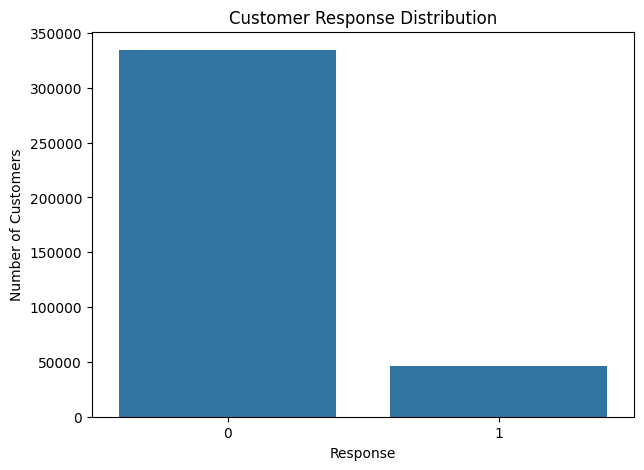

In [39]:
# EDA: Visualizing the distribution of the target variable
plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="Response")

plt.title("Customer Response Distribution")
plt.xlabel("Response")
plt.ylabel("Number of Customers")

plt.show()

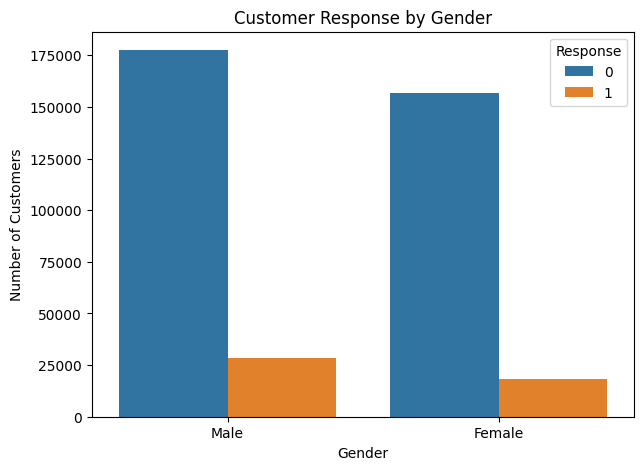

In [41]:
# EDA: analysis of gender vs response
plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="Gender", hue="Response")

plt.title("Customer Response by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

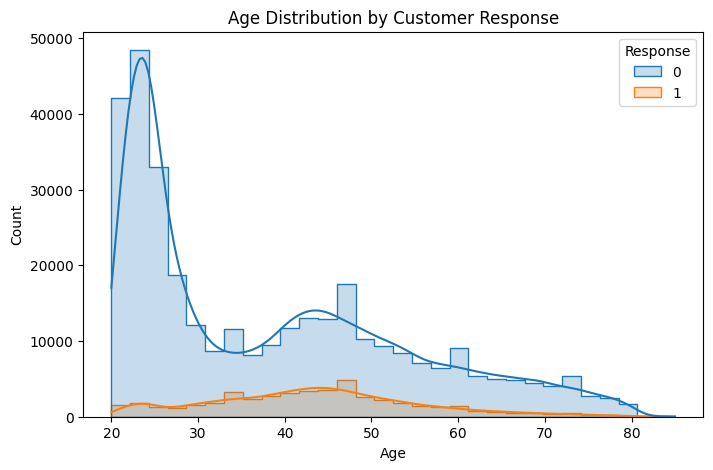

In [43]:
# EDA: Visualizing the distribution of Age by Response
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="Age",
    hue="Response",
    bins=30,
    kde=True,
    element="step"
)
plt.title("Age Distribution by Customer Response")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

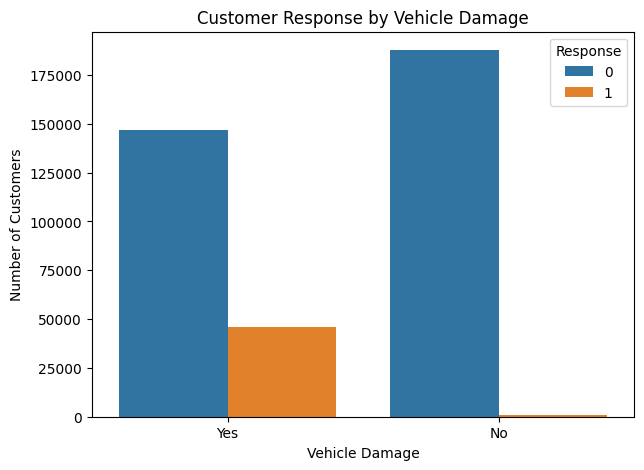

In [50]:
# EDA: Visualizing the distribution of Vehicle Damage by Response
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Vehicle_Damage",
    hue="Response"
)
plt.title("Customer Response by Vehicle Damage")
plt.xlabel("Vehicle Damage")
plt.ylabel("Number of Customers")

plt.show()

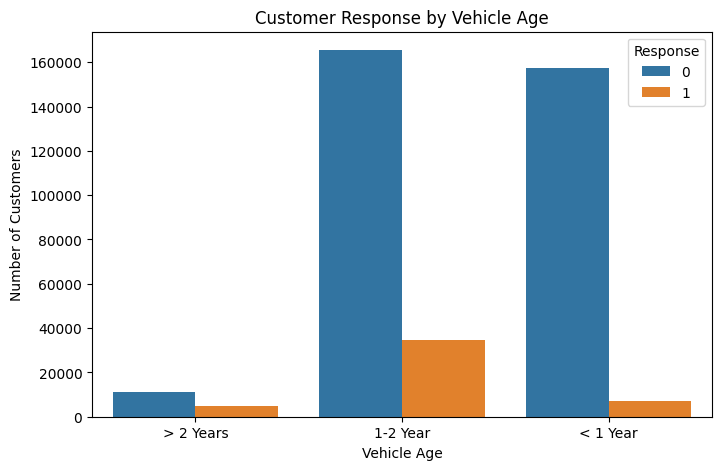

In [49]:
# EDA: Visualizing the distribution of Vehicle Age by Response
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Vehicle_Age",
    hue="Response"
)

plt.title("Customer Response by Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Number of Customers")

plt.show()

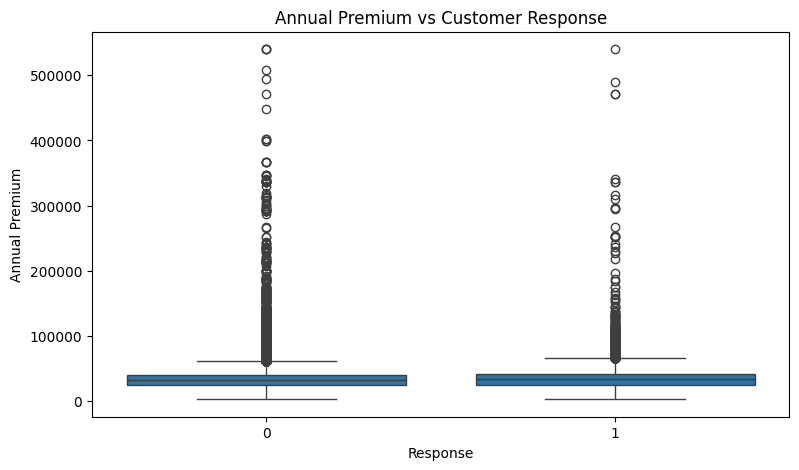

In [47]:
# EDA: Visualizing the distribution of Annual Premium by Response
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=data,
    x="Response",
    y="Annual_Premium"
)

plt.title("Annual Premium vs Customer Response")
plt.xlabel("Response")
plt.ylabel("Annual Premium")

plt.show()

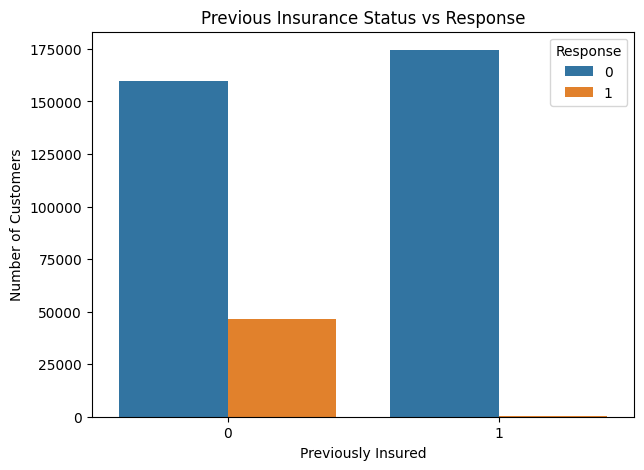

In [51]:
# EDA: Visualizing the distribution of Previous Insurance Status by Response
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Previously_Insured",
    hue="Response"
)

plt.title("Previous Insurance Status vs Response")
plt.xlabel("Previously Insured")
plt.ylabel("Number of Customers")

plt.show()

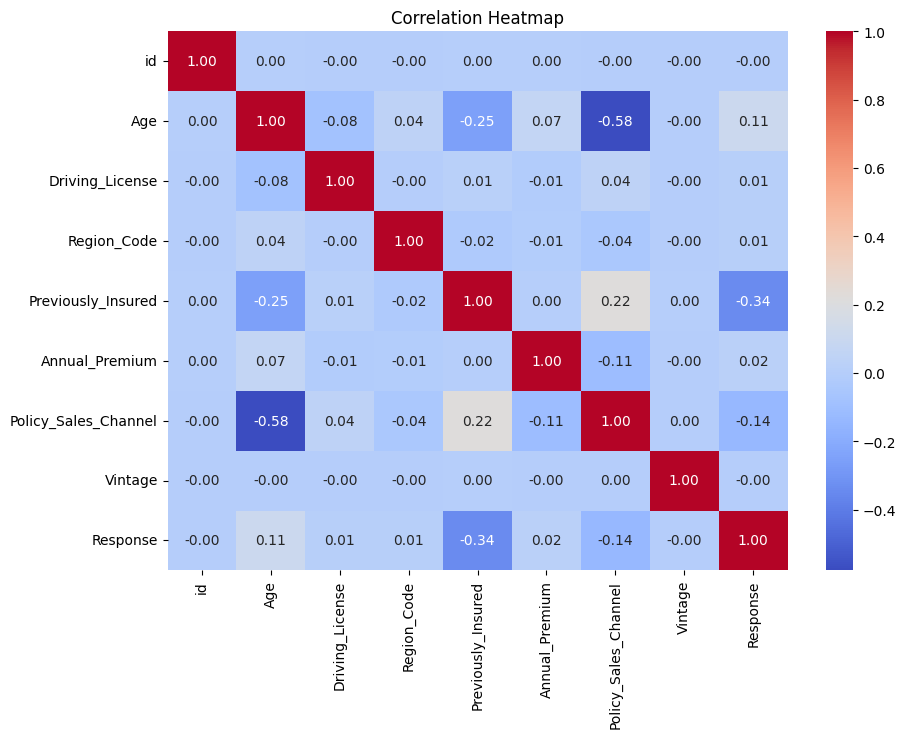

In [53]:
# EDA: Correlation Heatmap
numeric_df = data.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Feature Engineering